# Lecture 04 Bagging and Boosting 
## XGBoost

XGBoost is an efficient implementation of gradient boosting, which builds an ensemble of decision trees, where each new tree corrects errors made by the previous ones. The key components of XGBoost include:
- Gradient Boosting: At each step, XGBoost minimizes the loss function by using gradient descent.
- Regularization: XGBoost adds L1/L2 regularization to reduce overfitting.
- Learning Rate: A scaling factor is applied to control the impact of each tree.
- Loss Function: XGBoost supports custom loss functions, but common ones include regression loss (e.g., Mean Squared Error) and classification loss (e.g., Log cross-entropy).

Here’s how you can implement a basic version of XGBoost.

Step-by-Step XGBoost Implementation from Scratch
This is a simplified version of how XGBoost works internally. We'll focus on:
- Loss minimization via gradient boosting.
- Using decision trees as weak learners.
- Shrinking each tree's contribution using a learning rate.

/var/folders/_s/3jlv6djs67d5hnxcsy9mp4y00000gn/T/ipykernel_25576/3389742175.py:15: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  X = X.fillna(method='bfill').fillna(method='ffill')


RMSE: 52.75056504832956
Predictions: [4508.7104 3840.0444 3905.4358 4663.0864 4256.073  4133.5854 4187.005
 4511.8213 4149.49   2826.0037 4533.072  4256.2607 3974.0137 4587.0186
 3702.3533 4127.6655 3649.8293 4563.1987 3902.0574 3013.0244 4176.591
 3990.2407 3486.301  3684.21   4023.9119 3957.2153 4343.3906 3902.513
 4003.5598 4389.957  3917.664  3993.0693 2962.8335 3723.5688 3941.619
 2793.2534 4569.968  3326.6855 3810.3174 3440.4717 4650.21   4420.7085
 4180.857  4316.4395 4020.8757 3832.8132 4325.409  4510.2744 4140.116
 4281.8223 3751.6714 3858.8975 2610.8777 3840.5117 4386.2124 4092.3247
 4353.1733 2474.9727 3356.0093 3372.2556 4312.3584 4484.051  3313.3926
 4023.2065 3961.4492 4503.0713 4395.778  3466.6772 4743.901  4040.4355
 3201.0063 3568.4937 4525.2695 3366.2644 3815.3127 4380.388  4481.561
 4507.717  3018.8708 4245.9897 4092.8083 4165.1665 2666.8462 3913.201
 2704.4084 4488.9165 4089.5278 4125.0015 4159.738  3762.7568 4046.1318
 3992.9597 4543.653  4504.021  3840.407  3984.7

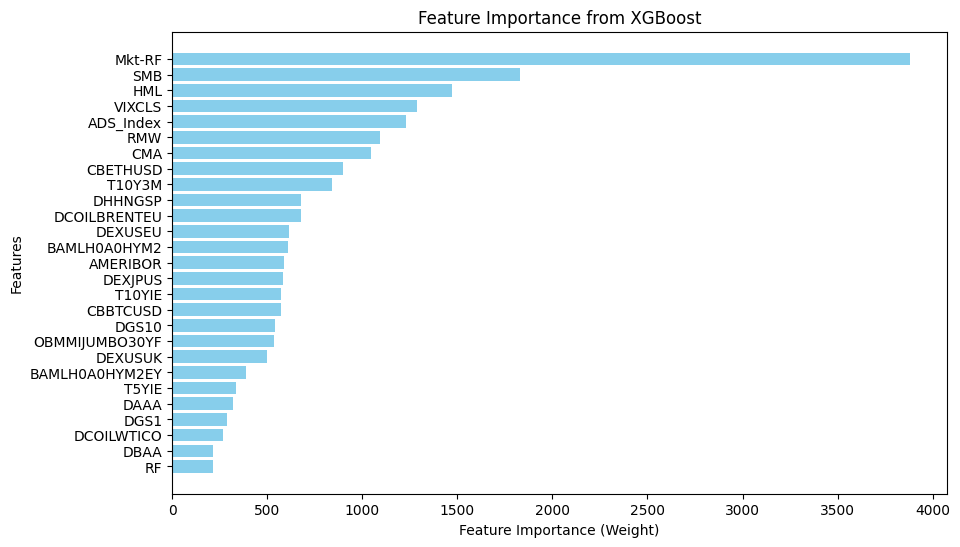

In [14]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

data = pd.read_csv('INFO6105_FeatureMart.csv')

data['Date'] = pd.to_datetime(data['Date'])

X = data.drop(columns=['Date', 'SP500'])  
y = data['SP500']  

X = X.fillna(method='bfill').fillna(method='ffill')

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

dtrain = xgb.DMatrix(X_train, label=y_train)
dtest = xgb.DMatrix(X_test, label=y_test)

params = {
    'objective': 'reg:squarederror',  # 回归问题
    'eval_metric': 'rmse',           # 均方根误差
    'learning_rate': 0.1,            # 学习率
    'max_depth': 100,                  # 树的最大深度
}

model = xgb.train(params, dtrain, num_boost_round=100)

y_pred = model.predict(dtest)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"RMSE: {rmse}")

print("Predictions:", y_pred)

y_pred_mean = np.mean(y_pred)
print(f"Average of predictions: {y_pred_mean}")

y_test_mean = np.mean(y_test)
print(f"Average of actual values: {y_test_mean}")

feature_importance = model.get_score(importance_type='weight')  # 'weight' 表示基于分裂次数的特征重要性
sorted_features = sorted(feature_importance.items(), key=lambda x: x[1], reverse=True)

feature_names = [item[0] for item in sorted_features]
importance_scores = [item[1] for item in sorted_features]

plt.figure(figsize=(10, 6))
plt.barh(feature_names, importance_scores, color='skyblue')
plt.xlabel('Feature Importance (Weight)')
plt.ylabel('Features')
plt.title('Feature Importance from XGBoost')
plt.gca().invert_yaxis() 
plt.show()


Key Components:
- Base Prediction: The initial prediction is the mean of y in regression problems.
- Gradient Calculation: For each iteration, we calculate the gradients of the loss function (MSE in this case).
- Tree Learning: Each decision tree (stump in our case) fits the residuals (gradients) to minimize the loss.
- Learning Rate: Each new tree's contribution is scaled by the learning rate to slow down learning and prevent overfitting.
- Predictions: The final prediction is the sum of the base prediction and the contributions of all trees.

This is a simplified version. Real XGBoost implementations include advanced optimization techniques, handling missing values, regularization, and feature importance scoring.

# XGBoost Using the xgboost Python Package

For real-world applications, it’s better to use the optimized XGBoost library (xgboost). Here's how you can use it:

In [12]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# Example Data: Generating random regression data
X, y = np.arange(100).reshape(50, 2), np.random.randn(50)

# Split the dataset into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Convert data into DMatrix (optimized data structure in XGBoost)
train_data = xgb.DMatrix(X_train, label=y_train)
test_data = xgb.DMatrix(X_test, label=y_test)

# XGBoost model parameters
params = {
    'objective': 'reg:squarederror',  # For regression
    'learning_rate': 0.1,
    'max_depth': 3,
    'n_estimators': 100
}

# Train the XGBoost model
model = xgb.train(params, train_data, num_boost_round=100)

# Predictions
y_pred = model.predict(test_data)

# Evaluate the model
mse_value = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse_value)


Mean Squared Error: 1.0363679857626316


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/xgboost/core.py:158: UserWarning: [17:39:05] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "n_estimators" } are not used.

  warnings.warn(smsg, UserWarning)


Key Steps:
- Data Preparation: Data is loaded into xgb.DMatrix, an optimized data structure in XGBoost.
- Model Parameters:
    - objective='reg:squarederror' specifies that it's a regression problem.
    - learning_rate: controls how much each tree contributes.
    - max_depth: limits the depth of each tree.
- Training: The model is trained using xgb.train(), with num_boost_round specifying the number of boosting rounds (iterations).
- Predictions: We use the trained model to predict on the test data.
- Evaluation: The mean_squared_error function is used to evaluate model performance on the test data.

Summary:
- XGBoost from Scratch: We built a simplified version to understand the inner workings, such as gradient calculation, tree building, and boosting.
- XGBoost Python Package: The xgboost library offers an optimized, feature-rich implementation for real-world applications.